<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_Four.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 4


# Probability Theory, Bayes' Theorem & N-gram Language Models
### An extensive, hands-on course using NumPy, pandas, SciPy & Matplotlib

**Roadmap**

| Part | Topic |
|---|---|
| 1 | Foundations of probability (sample spaces, axioms, set operations) |
| 2 | Conditional probability & independence |
| 3 | Random variables & common distributions |
| 4 | Expectation, variance, joint/marginal distributions |
| 5 | Bayes' Theorem — derivation, intuition, worked examples |
| 6 | Naive Bayes as an application of Bayes' Theorem |
| 7 | N-gram language models — chain rule, Markov assumption, MLE, smoothing |
| 8 | Generating text & evaluating with perplexity |
| 9 | Tying it together: a Bayes'-theorem-based N-gram spam classifier |
| 10 | Exercises |

We'll reuse the SMS spam/ham text data from the descriptive-statistics course as a running example, since language modelling needs real text.


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import product
from collections import Counter, defaultdict
import re, math, random

np.random.seed(42)
random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
print("Ready.")

Ready.


---
# Part 1 — Foundations of probability

A **sample space** $\Omega$ is the set of all possible outcomes of a random experiment. An **event** $A$ is a subset of $\Omega$.

**Kolmogorov's axioms:**
1. $P(A) \ge 0$ for any event $A$
2. $P(\Omega) = 1$
3. If $A_1, A_2, \dots$ are mutually exclusive, $P(A_1 \cup A_2 \cup \dots) = \sum_i P(A_i)$

Everything else in probability theory is derived from these three rules.

In [ ]:
# Simulate a sample space: rolling two fair dice
outcomes = list(product(range(1, 7), range(1, 7)))
print(f"|Omega| = {len(outcomes)}")
print(outcomes[:5], '...')

# Event A: sum of the two dice equals 7
A = [o for o in outcomes if sum(o) == 7]
P_A = len(A) / len(outcomes)
print(f"P(sum = 7) = {len(A)}/{len(outcomes)} = {P_A:.4f}")

|Omega| = 36
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5)] ...
P(sum = 7) = 6/36 = 0.1667


Sums to 1.0? -> True


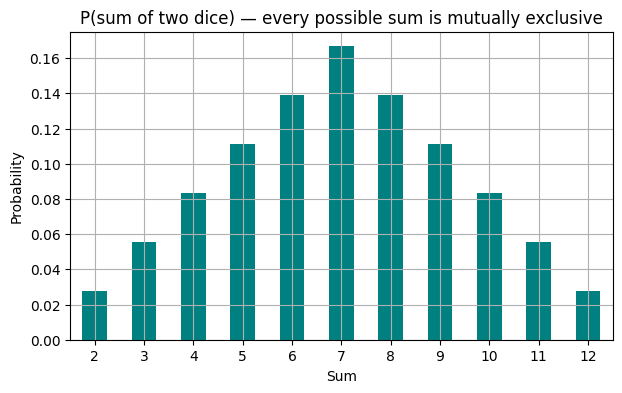

In [ ]:
# Verify axiom 2 and 3 empirically: P(Omega)=1, and mutually exclusive events add up
sums = [sum(o) for o in outcomes]
dist = pd.Series(sums).value_counts(normalize=True).sort_index()

print("Sums to 1.0? ->", np.isclose(dist.sum(), 1.0))

dist.plot(kind='bar', color='teal')
plt.title('P(sum of two dice) — every possible sum is mutually exclusive')
plt.xlabel('Sum'); plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.show()

### Set operations & probability rules

- **Union**: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ (subtract the overlap so it isn't double-counted)
- **Complement**: $P(A^c) = 1 - P(A)$

In [ ]:
# A: sum is even.  B: at least one die shows a 6.
A = set(o for o in outcomes if sum(o) % 2 == 0)
B = set(o for o in outcomes if 6 in o)

P_A, P_B = len(A)/36, len(B)/36
P_A_and_B = len(A & B)/36
P_A_or_B  = len(A | B)/36

print(f"P(A)={P_A:.3f}  P(B)={P_B:.3f}  P(A and B)={P_A_and_B:.3f}")
print(f"P(A or B) direct count = {P_A_or_B:.3f}")
print(f"P(A) + P(B) - P(A and B) = {P_A + P_B - P_A_and_B:.3f}  (should match)")

P(A)=0.500  P(B)=0.306  P(A and B)=0.139
P(A or B) direct count = 0.667
P(A) + P(B) - P(A and B) = 0.667  (should match)


---
# Part 2 — Conditional probability & independence

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

Reads as "the probability of $A$, given that we already know $B$ happened." Conditioning **shrinks the sample space** to just the outcomes consistent with $B$.

Two events are **independent** if $P(A \mid B) = P(A)$, equivalently $P(A \cap B) = P(A)P(B)$.

In [ ]:
# P(sum = 7 | at least one die is a 6)?
outcomes_set = set(outcomes)
B = set(o for o in outcomes_set if 6 in o)
A_and_B = set(o for o in B if sum(o) == 7)

P_B = len(B) / 36
P_A_given_B = len(A_and_B) / len(B)

print(f"P(at least one 6)        = {P_B:.4f}")
print(f"P(sum=7 | at least one 6) = {P_A_given_B:.4f}")
print(f"Compare to unconditional P(sum=7) = {6/36:.4f}  -> knowing B changed our belief about A")

P(at least one 6)        = 0.3056


P(sum=7 | at least one 6) = 0.1818
Compare to unconditional P(sum=7) = 0.1667  -> knowing B changed our belief about A


In [ ]:
# Independence check: die1 == 6  vs  die2 is even
C = set(o for o in outcomes_set if o[0] == 6)
D = set(o for o in outcomes_set if o[1] % 2 == 0)

P_C, P_D = len(C)/36, len(D)/36
P_C_and_D = len(C & D)/36

print(f"P(C)*P(D) = {P_C*P_D:.4f}")
print(f"P(C and D) = {P_C_and_D:.4f}")
print("Independent!" if np.isclose(P_C*P_D, P_C_and_D) else "Not independent")
# Makes sense: the two dice are physically separate, unrelated events.

P(C)*P(D) = 0.0833
P(C and D) = 0.0833
Independent!


---
# Part 3 — Random variables & common distributions

A **random variable** maps outcomes to numbers. Its **distribution** describes how probability is spread across those numbers.

- **Discrete**: Bernoulli, Binomial, Poisson — probability mass function (PMF)
- **Continuous**: Uniform, Normal — probability density function (PDF)

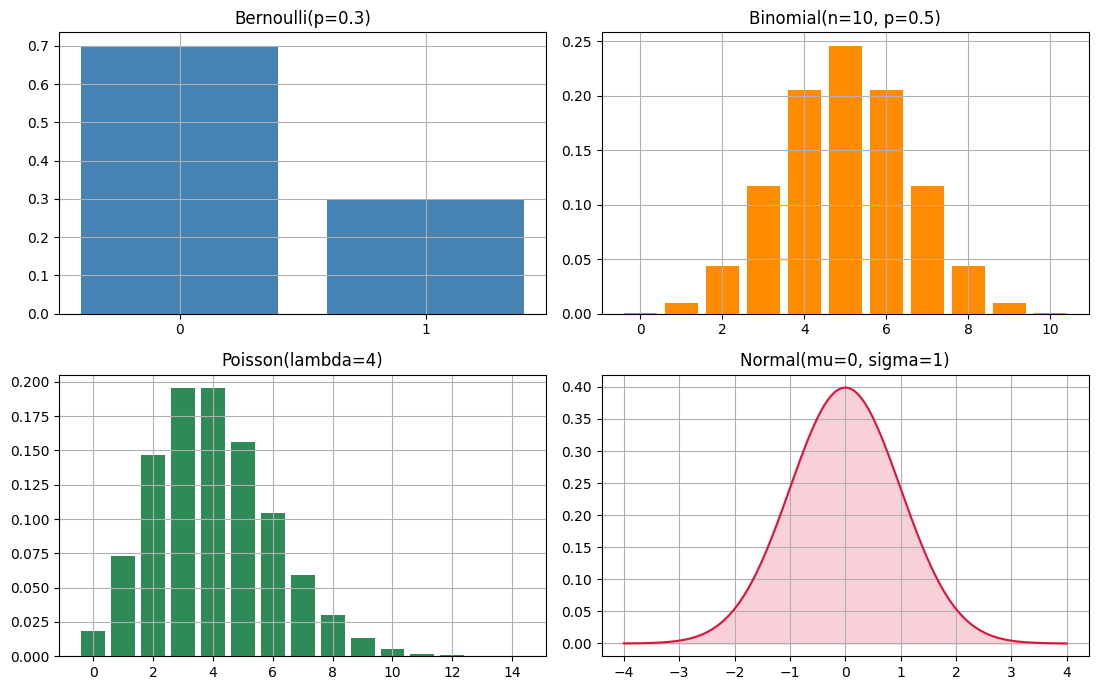

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Bernoulli(p=0.3)
x = [0, 1]; pmf = stats.bernoulli.pmf(x, p=0.3)
axes[0,0].bar(x, pmf, color='steelblue'); axes[0,0].set_title('Bernoulli(p=0.3)')
axes[0,0].set_xticks([0,1])

# Binomial(n=10, p=0.5): e.g. number of heads in 10 coin flips
x = np.arange(0, 11); pmf = stats.binom.pmf(x, n=10, p=0.5)
axes[0,1].bar(x, pmf, color='darkorange'); axes[0,1].set_title('Binomial(n=10, p=0.5)')

# Poisson(lambda=4): e.g. number of emails per hour
x = np.arange(0, 15); pmf = stats.poisson.pmf(x, mu=4)
axes[1,0].bar(x, pmf, color='seagreen'); axes[1,0].set_title('Poisson(lambda=4)')

# Normal(mu=0, sigma=1)
x = np.linspace(-4, 4, 200); pdf = stats.norm.pdf(x, loc=0, scale=1)
axes[1,1].plot(x, pdf, color='crimson'); axes[1,1].fill_between(x, pdf, alpha=0.2, color='crimson')
axes[1,1].set_title('Normal(mu=0, sigma=1)')

plt.tight_layout()
plt.show()

### The Binomial → Normal connection

The **Central Limit Theorem** is why the normal distribution shows up everywhere: sums of many small independent effects tend toward it, no matter the shape of the individual pieces.

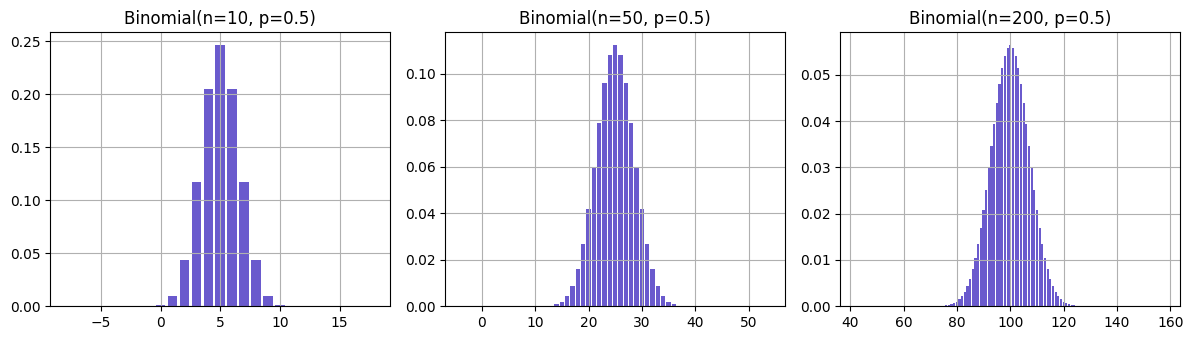

In [ ]:
# As n grows, Binomial(n, p) starts to look like a Normal distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)
for ax, n in zip(axes, [10, 50, 200]):
    x = np.arange(0, n+1)
    pmf = stats.binom.pmf(x, n=n, p=0.5)
    ax.bar(x, pmf, color='slateblue')
    ax.set_title(f'Binomial(n={n}, p=0.5)')
    ax.set_xlim(n*0.5 - 3*np.sqrt(n*0.25)*3, n*0.5 + 3*np.sqrt(n*0.25)*3)
plt.tight_layout()
plt.show()

---
# Part 4 — Expectation, variance & joint distributions

$$E[X] = \sum_x x \cdot P(X=x) \qquad \text{Var}(X) = E[(X-E[X])^2] = E[X^2] - (E[X])^2$$

A **joint distribution** $P(X, Y)$ describes two random variables together. From it we recover:
- **Marginal**: $P(X) = \sum_y P(X, Y=y)$ (sum out the other variable)
- **Conditional**: $P(X \mid Y) = P(X,Y) / P(Y)$

In [ ]:
# Expectation & variance of "sum of two dice" via simulation vs exact formula
sim = np.array([sum(o) for o in outcomes])
print(f"E[sum]   exact=7.00   simulated={sim.mean():.4f}")
print(f"Var(sum) exact=5.83   simulated={sim.var(ddof=0):.4f}")

E[sum]   exact=7.00   simulated=7.0000
Var(sum) exact=5.83   simulated=5.8333


In [ ]:
# Joint distribution table: die1 value vs whether the sum is >=8
df = pd.DataFrame(outcomes, columns=['die1', 'die2'])
df['high_sum'] = (df.die1 + df.die2 >= 8)

joint = pd.crosstab(df.die1, df.high_sum, normalize='all')
joint.columns = ['sum<8', 'sum>=8']
print("Joint distribution P(die1, high_sum):")
print(joint.round(3))

print("\nMarginal P(die1):")
print(joint.sum(axis=1).round(3))

print("\nConditional P(high_sum | die1=6):")
print((joint.loc[6] / joint.loc[6].sum()).round(3))

Joint distribution P(die1, high_sum):
      sum<8  sum>=8
die1               
1     0.167   0.000
2     0.139   0.028
3     0.111   0.056
4     0.083   0.083
5     0.056   0.111
6     0.028   0.139

Marginal P(die1):
die1
1    0.167
2    0.167
3    0.167
4    0.167
5    0.167
6    0.167
dtype: float64

Conditional P(high_sum | die1=6):
sum<8     0.167
sum>=8    0.833
Name: 6, dtype: float64


---
# Part 5 — Bayes' Theorem

Starting from the definition of conditional probability applied both ways:

$$P(A \cap B) = P(A \mid B)\,P(B) = P(B \mid A)\,P(A)$$

Divide both sides by $P(B)$:

$$\boxed{P(A \mid B) = \dfrac{P(B \mid A)\,P(A)}{P(B)}}$$

| Term | Name | Meaning |
|---|---|---|
| $P(A)$ | **Prior** | belief about $A$ before seeing evidence |
| $P(B \mid A)$ | **Likelihood** | how probable the evidence is, if $A$ is true |
| $P(B)$ | **Evidence** | overall probability of the evidence (a normalizer) |
| $P(A \mid B)$ | **Posterior** | updated belief about $A$ after seeing evidence $B$ |

Bayes' theorem is a rule for **updating beliefs in light of new evidence**.

### Worked example: the classic medical test problem

A disease affects **1%** of a population. A test for it is **95% sensitive** (detects the disease when present) and **90% specific** (correctly says "negative" when the disease is absent). Given a **positive** test, what's the probability of actually having the disease?

This is famous because intuition badly underestimates how much false positives dominate when the disease is rare.

In [ ]:
P_disease     = 0.01
P_pos_given_disease    = 0.95      # sensitivity
P_neg_given_no_disease = 0.90      # specificity
P_pos_given_no_disease = 1 - P_neg_given_no_disease

P_no_disease = 1 - P_disease

# Evidence: P(positive test) via the law of total probability
P_pos = (P_pos_given_disease * P_disease) + (P_pos_given_no_disease * P_no_disease)

# Bayes' theorem
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_pos

print(f"P(positive test)            = {P_pos:.4f}")
print(f"P(disease | positive test)  = {P_disease_given_pos:.4f}  <- only ~{P_disease_given_pos*100:.1f}%!")

P(positive test)            = 0.1085
P(disease | positive test)  = 0.0876  <- only ~8.8%!


Simulated P(disease | positive) = 0.0870  (matches the formula)


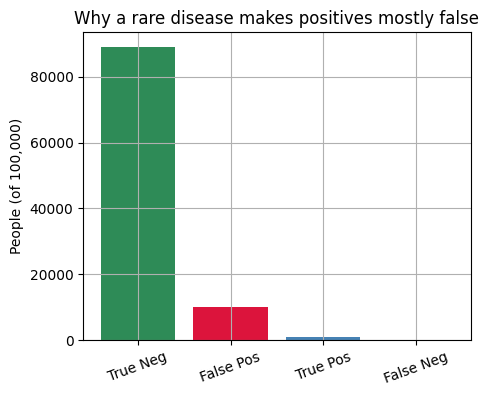

In [ ]:
# Visualize with a simulated population of 100,000 people
n = 100_000
has_disease = np.random.rand(n) < P_disease
test_pos = np.where(has_disease,
                     np.random.rand(n) < P_pos_given_disease,
                     np.random.rand(n) < P_pos_given_no_disease)

sim_posterior = has_disease[test_pos].mean()
print(f"Simulated P(disease | positive) = {sim_posterior:.4f}  (matches the formula)")

fig, ax = plt.subplots(figsize=(5,4))
counts = [
    ((~has_disease) & (~test_pos)).sum(),
    ((~has_disease) & test_pos).sum(),   # false positives — the big surprise
    (has_disease & test_pos).sum(),      # true positives — tiny by comparison
    (has_disease & (~test_pos)).sum(),
]
labels = ['True Neg', 'False Pos', 'True Pos', 'False Neg']
ax.bar(labels, counts, color=['seagreen','crimson','steelblue','orange'])
ax.set_ylabel('People (of 100,000)')
ax.set_title('Why a rare disease makes positives mostly false')
plt.xticks(rotation=20)
plt.show()

Even with a fairly accurate test, because the disease is rare, the **false positives from the huge healthy population** outnumber the **true positives from the tiny sick population**. This is the single most important intuition Bayes' theorem teaches.

### Sequential updating: the posterior becomes the next prior

Bayes' theorem composes naturally — each new piece of evidence updates our belief, and that updated belief becomes the prior for the next piece of evidence.

In [ ]:
# Suppose the patient takes the SAME test again and it's positive again
prior_2 = P_disease_given_pos    # yesterday's posterior is today's prior
P_pos_2 = (P_pos_given_disease * prior_2) + (P_pos_given_no_disease * (1 - prior_2))
posterior_2 = (P_pos_given_disease * prior_2) / P_pos_2

print(f"After 1 positive test: P(disease) = {P_disease_given_pos:.4f}")
print(f"After 2 positive tests: P(disease) = {posterior_2:.4f}")

After 1 positive test: P(disease) = 0.0876
After 2 positive tests: P(disease) = 0.4769


---
# Part 6 — Naive Bayes: Bayes' theorem for classification

To classify text as spam vs ham, we want $P(\text{spam} \mid \text{message})$. By Bayes' theorem:

$$P(\text{spam} \mid w_1, \dots, w_n) = \frac{P(w_1,\dots,w_n \mid \text{spam})\,P(\text{spam})}{P(w_1,\dots,w_n)}$$

The **"naive"** assumption: treat every word as conditionally independent given the class, turning one hard joint probability into a product of easy ones:

$$P(w_1,\dots,w_n \mid \text{spam}) \approx \prod_{i=1}^n P(w_i \mid \text{spam})$$

We don't need the denominator $P(w_1,\dots,w_n)$ for classification — it's the same for every class, so we just compare the numerators.

In [ ]:
SPAM_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
spam_df = pd.read_csv(SPAM_URL, sep='\t', header=None, names=['label', 'message'])

def tokenize(msg):
    return re.findall(r"[a-z']+", msg.lower())

# Priors
priors = spam_df['label'].value_counts(normalize=True)
print("Priors:\n", priors.round(3))

# Word likelihoods per class, with Laplace (add-1) smoothing
vocab = set(w for msg in spam_df['message'] for w in tokenize(msg))
V = len(vocab)

word_counts = {c: Counter(w for msg in spam_df.loc[spam_df.label==c, 'message'] for w in tokenize(msg))
               for c in ['spam', 'ham']}
total_words = {c: sum(word_counts[c].values()) for c in ['spam', 'ham']}

def word_loglik(word, cls):
    # P(word | class) with Laplace smoothing, in log-space for numerical stability
    count = word_counts[cls].get(word, 0)
    return math.log((count + 1) / (total_words[cls] + V))

def classify(message):
    tokens = tokenize(message)
    scores = {}
    for cls in ['spam', 'ham']:
        log_prob = math.log(priors[cls]) + sum(word_loglik(t, cls) for t in tokens)
        scores[cls] = log_prob
    return max(scores, key=scores.get), scores

test_msgs = [
    "WINNER!! You have been selected to receive a FREE cash prize, txt now",
    "hey are we still on for dinner tonight?",
]
for m in test_msgs:
    pred, scores = classify(m)
    print(f"'{m[:45]}...' -> {pred}   (scores: {scores})")

Priors:
 label
ham     0.866
spam    0.134
Name: proportion, dtype: float64
'WINNER!! You have been selected to receive a ...' -> spam   (scores: {'spam': -72.38312487604092, 'ham': -95.41175141432682})
'hey are we still on for dinner tonight?...' -> ham   (scores: {'spam': -59.30268262848201, 'ham': -48.75079912878602})


In [ ]:
# Evaluate accuracy on the full dataset (train == test here, just to illustrate — not a real holdout!)
preds = spam_df['message'].apply(lambda m: classify(m)[0])
accuracy = (preds == spam_df['label']).mean()
print(f"Naive Bayes training accuracy: {accuracy:.4f}")

pd.crosstab(spam_df['label'], preds, rownames=['actual'], colnames=['predicted'])

Naive Bayes training accuracy: 0.9916


predicted,ham,spam
actual,,
ham,4801,24
spam,23,724


---
# Part 7 — N-gram language models

An **N-gram** is a contiguous sequence of $N$ tokens. A language model assigns a probability to a sequence of words — used for text prediction, spelling correction, and as the "likelihood" piece of Bayesian text classifiers like the one above.

### The chain rule of probability

$$P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, \dots, w_{i-1})$$

Exact, but conditioning on the *entire* history is intractable — the number of possible histories explodes.

### The Markov assumption

Approximate "the whole history" with just the **last $N-1$ words**:

$$P(w_i \mid w_1,\dots,w_{i-1}) \approx P(w_i \mid w_{i-N+1}, \dots, w_{i-1})$$

- $N=1$ (**unigram**): $P(w_i)$ — ignores context entirely
- $N=2$ (**bigram**): $P(w_i \mid w_{i-1})$ — one word of context
- $N=3$ (**trigram**): $P(w_i \mid w_{i-2}, w_{i-1})$ — two words of context

In [ ]:
def get_ngrams(tokens, n):
    tokens = ['<s>']*(n-1) + tokens + ['</s>']
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

sample = tokenize("i will call you later")
print("tokens:", sample)
print("unigrams:", get_ngrams(sample, 1))
print("bigrams: ", get_ngrams(sample, 2))
print("trigrams:", get_ngrams(sample, 3))

tokens: ['i', 'will', 'call', 'you', 'later']
unigrams: [('i',), ('will',), ('call',), ('you',), ('later',), ('</s>',)]
bigrams:  [('<s>', 'i'), ('i', 'will'), ('will', 'call'), ('call', 'you'), ('you', 'later'), ('later', '</s>')]
trigrams: [('<s>', '<s>', 'i'), ('<s>', 'i', 'will'), ('i', 'will', 'call'), ('will', 'call', 'you'), ('call', 'you', 'later'), ('you', 'later', '</s>')]


### Estimating N-gram probabilities: Maximum Likelihood Estimation (MLE)

$$P(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$$

i.e. "of all the times we saw $w_{i-1}$, what fraction of the time was $w_i$ next?" — a direct application of the conditional-probability definition from Part 2.

In [ ]:
# Build a bigram model on the ham messages (normal conversational English)
ham_corpus = [tokenize(m) for m in spam_df.loc[spam_df.label=='ham', 'message']]

bigram_counts  = defaultdict(Counter)   # bigram_counts[w1][w2] = count
unigram_counts = Counter()

for tokens in ham_corpus:
    for (w1,), (w2,) in zip(get_ngrams(tokens, 1)[:-1], get_ngrams(tokens, 1)[1:]):
        pass  # (kept simple; real bigram extraction below)

for tokens in ham_corpus:
    padded = ['<s>'] + tokens + ['</s>']
    for w1, w2 in zip(padded[:-1], padded[1:]):
        bigram_counts[w1][w2] += 1
        unigram_counts[w1] += 1

def bigram_prob(w1, w2, k=0):
    # k=0 -> plain MLE, k=1 -> Laplace smoothing (see next section)
    V = len(unigram_counts)
    return (bigram_counts[w1][w2] + k) / (unigram_counts[w1] + k*V)

print(f"P('you' | 'call')  = {bigram_prob('call', 'you'):.4f}")
print(f"P('later' | 'call') = {bigram_prob('call', 'later'):.4f}")
print(f"Most likely words after 'call':")
print(bigram_counts['call'].most_common(5))

P('you' | 'call')  = 0.1050
P('later' | 'call') = 0.1639
Most likely words after 'call':
[('me', 58), ('later', 39), ('you', 25), ('</s>', 13), ('u', 7)]


### The zero-probability problem & Laplace smoothing

MLE assigns **zero probability** to any bigram never seen in training — one unseen word anywhere in a sentence makes the *whole sentence's* probability zero, via the chain-rule product. **Add-one (Laplace) smoothing** fixes this by pretending every possible bigram was seen once extra:

$$P_{\text{Laplace}}(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i) + 1}{\text{count}(w_{i-1}) + V}$$

where $V$ is the vocabulary size.

MLE P(unseen bigram)      = 0.000000
Laplace-smoothed P        = 0.000140   (small but non-zero)


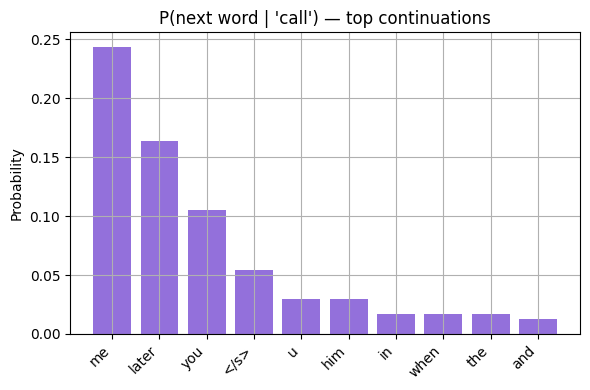

In [ ]:
unseen = bigram_prob('call', 'zzqx')       # a bigram that never occurred
smoothed = bigram_prob('call', 'zzqx', k=1)
print(f"MLE P(unseen bigram)      = {unseen:.6f}")
print(f"Laplace-smoothed P        = {smoothed:.6f}   (small but non-zero)")

fig, ax = plt.subplots(figsize=(6,4))
words, counts = zip(*bigram_counts['call'].most_common(10))
ax.bar(words, [c/unigram_counts['call'] for c in counts], color='mediumpurple')
ax.set_title("P(next word | 'call') — top continuations")
ax.set_ylabel('Probability')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# Part 8 — Generating text & evaluating with perplexity

### Generation
Sample the next word from $P(w_i \mid w_{i-1})$ repeatedly — a random walk through the bigram distribution.

In [ ]:
def generate(start='<s>', max_len=15):
    w1 = start
    result = []
    for _ in range(max_len):
        choices = bigram_counts[w1]
        if not choices:
            break
        words, wts = zip(*choices.items())
        w2 = random.choices(words, weights=wts, k=1)[0]
        if w2 == '</s>':
            break
        result.append(w2)
        w1 = w2
    return ' '.join(result)

for _ in range(5):
    print('->', generate())

-> mm that was the wheel
-> yeh i get some leads on my house maid is there before fucking minutes a
-> i'll go to great day
-> i start around the easiest way congrats treat
-> really just gonna call my love you in the evo i am late in today


### Perplexity: how well does the model predict held-out text?

$$\text{Perplexity}(W) = P(w_1,\dots,w_n)^{-1/n} = \exp\!\left(-\frac{1}{n}\sum_i \log P(w_i \mid w_{i-1})\right)$$

Perplexity is the **effective average number of equally-likely word choices** the model is "confused between" at each step. **Lower is better.** A perfect model has perplexity 1; a model that's totally lost has perplexity = vocabulary size.

In [ ]:
def perplexity(tokens, k=1):
    padded = ['<s>'] + tokens + ['</s>']
    log_probs = [math.log(bigram_prob(w1, w2, k=k)) for w1, w2 in zip(padded[:-1], padded[1:])]
    return math.exp(-sum(log_probs) / len(log_probs))

test_sentences = [
    tokenize("call you later ok"),          # plausible, ham-like
    tokenize("zebra quantum firewall exam"),  # implausible word salad
]
for s in test_sentences:
    print(f"{' '.join(s):40s} -> perplexity = {perplexity(s):.1f}")

call you later ok                        -> perplexity = 601.3
zebra quantum firewall exam              -> perplexity = 6172.0


The plausible, conversational sentence gets a **much lower perplexity** than the word-salad sentence — the model correctly finds it far less surprising, because its bigrams actually occurred in ordinary text messages.

---
# Part 9 — Tying it together: N-grams inside a Bayesian classifier

Part 6's Naive Bayes classifier used **unigram** likelihoods ($P(w_i \mid \text{class})$, no context). We can upgrade it to a **bigram** language model per class — giving the classifier a sense of word *order*, not just word presence, while still plugging into the same Bayes'-theorem framework from Part 5.

In [ ]:
def build_bigram_model(messages):
    bc, uc = defaultdict(Counter), Counter()
    for msg in messages:
        padded = ['<s>'] + tokenize(msg) + ['</s>']
        for w1, w2 in zip(padded[:-1], padded[1:]):
            bc[w1][w2] += 1
            uc[w1] += 1
    return bc, uc

models = {}
for cls in ['spam', 'ham']:
    models[cls] = build_bigram_model(spam_df.loc[spam_df.label==cls, 'message'])

V_all = len(set(w for msgs in [spam_df['message']] for m in msgs for w in tokenize(m)))

def class_bigram_logprob(message, cls):
    bc, uc = models[cls]
    padded = ['<s>'] + tokenize(message) + ['</s>']
    total = 0.0
    for w1, w2 in zip(padded[:-1], padded[1:]):
        p = (bc[w1][w2] + 1) / (uc[w1] + V_all)   # Laplace smoothing
        total += math.log(p)
    return total

def classify_bigram(message):
    scores = {cls: math.log(priors[cls]) + class_bigram_logprob(message, cls) for cls in ['spam','ham']}
    return max(scores, key=scores.get), scores

for m in test_msgs:
    pred, scores = classify_bigram(m)
    print(f"'{m[:45]}...' -> {pred}")

'WINNER!! You have been selected to receive a ...' -> spam
'hey are we still on for dinner tonight?...' -> ham


Unigram Naive Bayes accuracy: 0.9916
Bigram  Naive Bayes accuracy: 0.9973


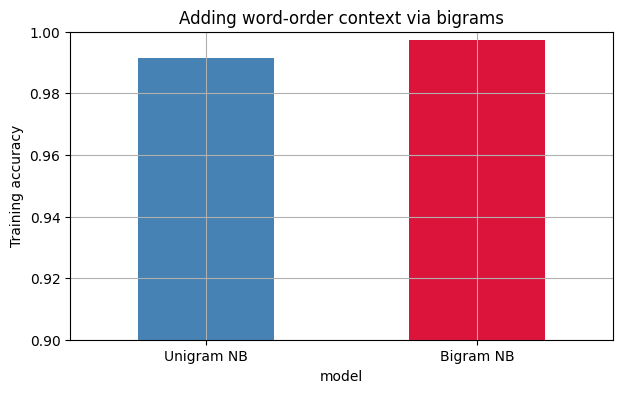

In [ ]:
preds_bigram = spam_df['message'].apply(lambda m: classify_bigram(m)[0])
acc_bigram = (preds_bigram == spam_df['label']).mean()

print(f"Unigram Naive Bayes accuracy: {accuracy:.4f}")
print(f"Bigram  Naive Bayes accuracy: {acc_bigram:.4f}")

pd.DataFrame({'model': ['Unigram NB', 'Bigram NB'], 'accuracy': [accuracy, acc_bigram]}) \
  .plot(x='model', y='accuracy', kind='bar', legend=False, color=['steelblue','crimson'])
plt.ylim(0.9, 1.0)
plt.ylabel('Training accuracy')
plt.title('Adding word-order context via bigrams')
plt.xticks(rotation=0)
plt.show()

This is the same Bayes' theorem from Part 5 — $P(\text{class}\mid\text{message}) \propto P(\text{message}\mid\text{class})\,P(\text{class})$ — just with a richer, N-gram-based likelihood $P(\text{message}\mid\text{class})$ instead of a bag-of-words one. This is exactly the lineage from classic statistical NLP: probability axioms -> conditional probability -> Bayes' theorem -> N-gram language models -> Bayesian text classification.

---
# Part 10 — Exercises

1. **Foundations**: Compute $P(\text{both dice show the same number})$ by enumeration, and verify it against $1/6$.
2. **Bayes**: Redo the medical-test example with a disease prevalence of 10% instead of 1%. How much does the posterior change? Why?
3. **Naive Bayes**: The classifier above evaluates on its own training data (no held-out test set). Split `spam_df` into 80% train / 20% test and recompute accuracy — does it drop?
4. **N-grams**: Build a **trigram** model ($P(w_i \mid w_{i-2}, w_{i-1})$) on the ham corpus and compare perplexity on the two `test_sentences` to the bigram model's.
5. **Generation**: Modify `generate()` to start from a specific seed word (e.g. `'free'`) and generate 10 spam-style continuations. What patterns do you notice?
6. **Challenge**: Laplace (add-1) smoothing is known to overcorrect on large vocabularies. Look up **add-k smoothing** (k<1) or **Kneser-Ney smoothing** and try implementing add-k with $k=0.1$ — does perplexity improve?
